Stage 2: Floorplan unit layout generation
- Split in lower and upper sections
- The order for the exec maisonette will be: corr_end, corr, (4m gap) corr_mirror_y, corr, corr_mirror_y, corr, (4m gap)corr_mirror_y, corr_end_mirror_y
- Add numberStories = 10

In [2]:
import json
from copy import deepcopy
from pathlib import Path


INPUT_JSON = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\unittemplates_EM.json")
OUTPUT_JSON = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk863_EM.json")

GAP = 4.0
NUMBER_STORIES = 10

UNIT_ORDER = [
    "exec_maisonette_corr_end",
    "exec_maisonette_corr",
    "exec_maisonette_corr_mirror_y",
    "exec_maisonette_corr",
    "exec_maisonette_corr_mirror_y",
    "exec_maisonette_corr",
    "exec_maisonette_corr_mirror_y",
    "exec_maisonette_corr_end_mirror_y",
]

GAP_BEFORE = {2, 6}


def level_bounds(level):
    points = [
        p
        for room in level["rooms"].values()
        for p in room["coordinates"]
    ]

    xs, ys = zip(*points)

    return min(xs), max(xs), min(ys), max(ys)


def unit_bounds(unit):
    lower = level_bounds(unit["lower"])
    upper = level_bounds(unit["upper"])

    return (
        min(lower[0], upper[0]),
        max(lower[1], upper[1]),
        min(lower[2], upper[2]),
        max(lower[3], upper[3]),
    )


def move_level(level, dx=0, dy=0):
    level = deepcopy(level)

    for room in level["rooms"].values():
        room["coordinates"] = [
            [x + dx, y + dy]
            for x, y in room["coordinates"]
        ]

    for facade in level.get("facades", []):
        for key in ("start", "end"):
            if key in facade:
                x, y = facade[key]
                facade[key] = [x + dx, y + dy]

        if "points" in facade:
            facade["points"] = [
                [x + dx, y + dy]
                for x, y in facade["points"]
            ]

    return level


def move_unit(unit, dx=0, dy=0):
    return {
        "lower": move_level(unit["lower"], dx, dy),
        "upper": move_level(unit["upper"], dx, dy),
    }


def build_block(templates):
    units = {}
    current_x = 0

    for i, template_name in enumerate(UNIT_ORDER):

        unit = deepcopy(templates[template_name])

        min_x, max_x, min_y, _ = unit_bounds(unit)

        if i in GAP_BEFORE:
            current_x += GAP

        dx = current_x - min_x
        dy = -min_y

        unit = move_unit(unit, dx, dy)

        units[str(i + 1)] = unit

        current_x = unit_bounds(unit)[1]

    lower = {}
    upper = {}

    for number, unit in units.items():
        lower[number] = unit["lower"]
        upper[number] = unit["upper"]

    return {
        "lower": lower,
        "upper": upper,
    }


def save_compact_json(block, output_path):
    lines = ["{"]

    for level_index, level_name in enumerate(("lower", "upper")):
        lines.append(f'    "{level_name}": {{')

        units = list(block[level_name].items())

        for unit_index, (number, unit) in enumerate(units):
            lines.append(f'        "{number}": {{')
            lines.append('            "rooms": {')

            rooms = list(unit["rooms"].items())

            for i, (room_name, room) in enumerate(rooms):
                comma = "," if i < len(rooms) - 1 else ""

                lines.append(
                    f'                "{room_name}": '
                    f'{json.dumps(room, separators=(",", ":"))}{comma}'
                )

            lines.append("            },")
            lines.append('            "facades": [')

            facades = unit.get("facades", [])

            for i, facade in enumerate(facades):
                comma = "," if i < len(facades) - 1 else ""

                lines.append(
                    f'                '
                    f'{json.dumps(facade, separators=(",", ":"))}{comma}'
                )

            lines.append("            ]")

            comma = "," if unit_index < len(units) - 1 else ""
            lines.append(f"        }}{comma}")

        lines.append("    },")

    lines.append(f'    "numberStories": {NUMBER_STORIES}')
    lines.append("}")

    output_path.write_text(
        "\n".join(lines),
        encoding="utf-8"
    )


with INPUT_JSON.open(encoding="utf-8") as f:
    templates = json.load(f)


block = build_block(templates)

save_compact_json(
    block,
    OUTPUT_JSON
)

print(f"Saved: {OUTPUT_JSON}")

Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk863_EM.json


Stage 3 (for testing only):
- Single floor but with elevation 
- Void deck to lvl 2: 3.6m 
- Between levels onwards: 2.8m 
- Convert into IDF but no multiple stories (ignores numberStories) 
- Generates base blk 863 template of 2 stories (lower and upper, where lower has z height 3.6m and upper is 3.6+2.8)

Checks
- 80 zones
- 48 windows
- 32 HVAC zones

IDF saved to: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\blk863_EM_single.idf


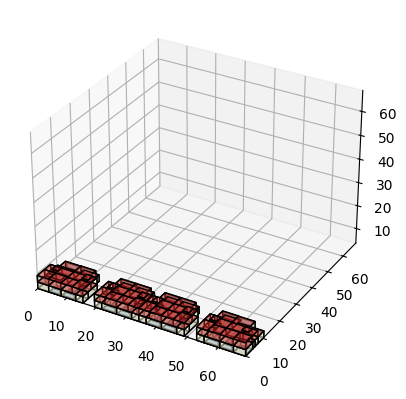

In [3]:
"""Convert a lower/upper maisonette JSON into a 2-level EnergyPlus IDF
using geomeppy/eppy objects throughout.

Key project rules
-----------------
* JSON numberStories is ignored.
* lower: z = 3.6 to 6.4 m
* upper: z = 6.4 to 9.2 m
* every room polygon becomes an EnergyPlus Zone
* naming uses "Unit", never geomeppy's default "Block"
* HVAC only for livingroom/masterroom/bedroom*
* cooling setpoint = 25 C
* no heating (Always Off)
* dehumidification max RH = 60%, no humidifier
* infiltration:
    - bedroom/masterroom = 0.2 ACH
    - livingroom = 1.0 ACH base with Living_Infiltration_AirCon schedule
      giving 0.2 ACH when AC is on and 1.0 ACH when AC is off
    - other rooms = 1.0 ACH
* floors/ceilings = Adiabatic, NoSun, NoWind
* ordinary exterior walls = Outdoors, SunExposed, WindExposed
* corridor facades = Outdoors, NoSun, WindExposed
* window facades = Outdoors, SunExposed, WindExposed
* window+corridor overlap = NoSun, WindExposed, with window retained
"""

import json
import math
from collections import defaultdict
from pathlib import Path

from geomeppy import IDF
from shapely.geometry import LineString, Point, Polygon
from shapely.geometry.polygon import orient
from shapely.validation import explain_validity


# ============================================================
# FILE PATHS
# ============================================================

IDD_PATH = Path(
    r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
)

INPUT_JSON = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk863_EM.json"
)

IDF_TEMPLATE = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\idf_template_SL.idf"
)

OUTPUT_IDF = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\blk863_EM_single.idf"
)


# ============================================================
# PROJECT SETTINGS
# ============================================================

BASE_ELEVATION = 3.6
FLOOR_HEIGHT = 2.8

LEVELS = {
    "lower": (
        BASE_ELEVATION,
        BASE_ELEVATION + FLOOR_HEIGHT,
    ),
    "upper": (
        BASE_ELEVATION + FLOOR_HEIGHT,
        BASE_ELEVATION + 2 * FLOOR_HEIGHT,
    ),
}

GEOMETRY_TOLERANCE = 1.0e-5
AREA_TOLERANCE = 1.0e-7

WALL_CONSTRUCTION = "Project Wall"
FLOOR_CONSTRUCTION = "Project Floor"
ROOF_CONSTRUCTION = "Project Flat Roof"
WINDOW_CONSTRUCTION = "Project External Window"

ALWAYS_ON_SCHEDULE = "Always On"
ALWAYS_OFF_SCHEDULE = "Always Off"
AC_SCHEDULE = "AirCon_normal"
LIVING_INFILTRATION_SCHEDULE = "Living_Infiltration_AirCon"

THERMOSTAT_NAME = "Zone Stat"
COOLING_SETPOINT = 25.0
MAX_RH = 60.0


# ============================================================
# GENERAL HELPERS
# ============================================================

def clean_room_type(name):
    return (
        str(name)
        .lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )


def is_conditioned(room_name):
    room = clean_room_type(room_name)
    return (
        room == "livingroom"
        or room.startswith("masterroom")
        or room.startswith("bedroom")
    )


def get_named_object(idf_temp, object_type, name):
    for obj in idf_temp.idfobjects[object_type.upper()]:
        if str(obj.Name).strip().lower() == str(name).strip().lower():
            return obj
    return None


def point_key(point):
    return (
        round(float(point[0]), 6),
        round(float(point[1]), 6),
    )


def segment_key(a, b):
    return tuple(sorted((point_key(a), point_key(b))))


def normalise_polygon(coords, context="polygon"):
    polygon = Polygon(coords)

    if polygon.is_valid:
        return orient(polygon, sign=1.0), False

    repaired = polygon.buffer(0)

    if (
        repaired.geom_type == "Polygon"
        and repaired.is_valid
        and abs(repaired.area - polygon.area) <= AREA_TOLERANCE
        and repaired.area > AREA_TOLERANCE
    ):
        return orient(repaired, sign=1.0), True

    raise ValueError(
        f"Invalid polygon: {context}. "
        f"Reason: {explain_validity(polygon)}"
    )


def _intersection_points(intersection):
    if intersection.is_empty:
        return

    if intersection.geom_type == "Point":
        yield intersection
        return

    if intersection.geom_type == "MultiPoint":
        yield from intersection.geoms
        return

    if intersection.geom_type == "LineString":
        coords = list(intersection.coords)
        if coords:
            yield Point(coords[0])
            yield Point(coords[-1])
        return

    if hasattr(intersection, "geoms"):
        for geom in intersection.geoms:
            yield from _intersection_points(geom)


def split_polygon_boundary(coords, splitters):
    polygon = orient(Polygon(coords), sign=1.0)
    ring = list(polygon.exterior.coords)[:-1]
    result = []

    for a, b in zip(ring, ring[1:] + ring[:1]):
        edge = LineString([a, b])
        distances = {0.0, edge.length}

        for splitter in splitters:
            intersection = edge.intersection(splitter)

            for point in _intersection_points(intersection):
                if edge.distance(point) <= GEOMETRY_TOLERANCE:
                    distance = edge.project(point)
                    distances.add(
                        max(
                            0.0,
                            min(edge.length, distance),
                        )
                    )

        ordered = sorted(distances)

        for d0, d1 in zip(ordered[:-1], ordered[1:]):
            if d1 - d0 <= GEOMETRY_TOLERANCE:
                continue

            p0 = edge.interpolate(d0)
            p1 = edge.interpolate(d1)

            result.append(
                (
                    (p0.x, p0.y),
                    (p1.x, p1.y),
                )
            )

    return result


def facade_segments(unit_data):
    segments = []

    for facade in unit_data.get("facades", []):
        facade_type = str(
            facade.get("type", "")
        ).strip().lower()

        if facade_type not in {"window", "corridor"}:
            continue

        if "points" in facade:
            points = facade["points"]
        else:
            points = [
                facade["start"],
                facade["end"],
            ]

        wwr = float(facade.get("WWR", 0.5))

        if not 0.0 <= wwr < 1.0:
            raise ValueError(
                f"WWR must be >= 0 and < 1. Got {wwr}."
            )

        for start, end in zip(points[:-1], points[1:]):
            line = LineString([start, end])

            if line.length <= GEOMETRY_TOLERANCE:
                raise ValueError(
                    f"Zero-length facade segment: {facade}"
                )

            segments.append(
                (line, facade_type, wwr)
            )

    return segments


def load_and_validate_json(json_path):
    data = json.loads(
        Path(json_path).read_text(encoding="utf-8")
    )

    for level in ("lower", "upper"):
        if level not in data:
            raise ValueError(
                f"JSON must contain '{level}'."
            )

    records = defaultdict(list)

    for level in ("lower", "upper"):
        for unit_number, unit_data in data[level].items():
            facade_segments(unit_data)

            for room_name, room_data in unit_data["rooms"].items():
                polygon, _ = normalise_polygon(
                    room_data["coordinates"],
                    context=f"{level} Unit {unit_number} {room_name}",
                )

                records[level].append(
                    (
                        str(unit_number),
                        room_name,
                        polygon,
                    )
                )

    overlaps = []

    for level, level_records in records.items():
        for i, (unit_a, room_a, poly_a) in enumerate(level_records):
            for unit_b, room_b, poly_b in level_records[i + 1:]:
                area = poly_a.intersection(poly_b).area

                if area > AREA_TOLERANCE:
                    overlaps.append(
                        f"{level}: Unit {unit_a} {room_a} <-> "
                        f"Unit {unit_b} {room_b}: {area:.6f} m2"
                    )

    if overlaps:
        raise ValueError(
            "Room polygons overlap:\n  - "
            + "\n  - ".join(overlaps)
        )

    return data


# ============================================================
# INITIALISE IDF
# ============================================================

def initialise_idf(idd_path, template_path):
    try:
        IDF.setiddname(str(idd_path))
    except Exception:
        # IDD may already be loaded in the current Jupyter/Python session.
        pass

    return IDF(str(template_path))


# ============================================================
# ZONES
# ============================================================

def create_zone(idf_temp, zone_name):
    return idf_temp.newidfobject(
        "ZONE",
        Name=zone_name,
        Direction_of_Relative_North=0,
        X_Origin=0,
        Y_Origin=0,
        Z_Origin=0,
        Type=1,
        Multiplier=1,
        Ceiling_Height="autocalculate",
        Volume="autocalculate",
        Floor_Area="autocalculate",
        Part_of_Total_Floor_Area="Yes",
    )


# ============================================================
# SURFACES / WALLS
# ============================================================

def create_surface(
    idf_temp,
    name,
    surface_type,
    construction,
    zone_name,
    outside_boundary,
    outside_object,
    sun_exposure,
    wind_exposure,
    vertices,
):
    obj = idf_temp.newidfobject(
        "BUILDINGSURFACE:DETAILED",
        Name=name,
        Surface_Type=surface_type,
        Construction_Name=construction,
        Zone_Name=zone_name,
        Outside_Boundary_Condition=outside_boundary,
        Outside_Boundary_Condition_Object=outside_object,
        Sun_Exposure=sun_exposure,
        Wind_Exposure=wind_exposure,
        View_Factor_to_Ground="autocalculate",
        Number_of_Vertices=len(vertices),
    )

    for index, (x, y, z) in enumerate(vertices, start=1):
        setattr(obj, f"Vertex_{index}_Xcoordinate", float(x))
        setattr(obj, f"Vertex_{index}_Ycoordinate", float(y))
        setattr(obj, f"Vertex_{index}_Zcoordinate", float(z))

    return obj


# ============================================================
# WINDOWS
# ============================================================

def create_window(
    idf_temp,
    name,
    wall_name,
    a,
    b,
    z0,
    z1,
    wwr,
):
    if wwr <= 0:
        return None

    horizontal_fraction = max(
        0.8,
        min(0.98, math.sqrt(wwr)),
    )

    vertical_fraction = (
        wwr / horizontal_fraction
    )

    if vertical_fraction > 0.98:
        vertical_fraction = 0.98
        horizontal_fraction = (
            wwr / vertical_fraction
        )

    ax, ay = a
    bx, by = b

    start_fraction = (
        1.0 - horizontal_fraction
    ) / 2.0

    end_fraction = (
        1.0 + horizontal_fraction
    ) / 2.0

    p1 = (
        ax + (bx - ax) * start_fraction,
        ay + (by - ay) * start_fraction,
    )

    p2 = (
        ax + (bx - ax) * end_fraction,
        ay + (by - ay) * end_fraction,
    )

    wall_height = z1 - z0

    win_z0 = (
        z0
        + wall_height
        * (1.0 - vertical_fraction)
        / 2.0
    )

    win_z1 = (
        z1
        - wall_height
        * (1.0 - vertical_fraction)
        / 2.0
    )

    obj = idf_temp.newidfobject(
        "FENESTRATIONSURFACE:DETAILED",
        Name=name,
        Surface_Type="Window",
        Construction_Name=WINDOW_CONSTRUCTION,
        Building_Surface_Name=wall_name,
        View_Factor_to_Ground="autocalculate",
        Multiplier=1,
        Number_of_Vertices=4,
    )

    vertices = [
        (p1[0], p1[1], win_z0),
        (p2[0], p2[1], win_z0),
        (p2[0], p2[1], win_z1),
        (p1[0], p1[1], win_z1),
    ]

    for index, (x, y, z) in enumerate(vertices, start=1):
        setattr(obj, f"Vertex_{index}_Xcoordinate", float(x))
        setattr(obj, f"Vertex_{index}_Ycoordinate", float(y))
        setattr(obj, f"Vertex_{index}_Zcoordinate", float(z))

    return obj


# ============================================================
# INFILTRATION
# ============================================================

def add_infiltration(
    idf_temp,
    zone_name,
    room_name,
):
    room = clean_room_type(room_name)

    if room == "livingroom":
        schedule = LIVING_INFILTRATION_SCHEDULE
        ach = 1.0

    elif (
        room.startswith("masterroom")
        or room.startswith("bedroom")
    ):
        schedule = ALWAYS_ON_SCHEDULE
        ach = 0.2

    else:
        schedule = ALWAYS_ON_SCHEDULE
        ach = 1.0

    return idf_temp.newidfobject(
        "ZONEINFILTRATION:DESIGNFLOWRATE",
        Name=f"{zone_name} Infiltration",
        Zone_or_ZoneList_Name=zone_name,
        Schedule_Name=schedule,
        Design_Flow_Rate_Calculation_Method="AirChanges/Hour",
        Air_Changes_per_Hour=ach,
        Constant_Term_Coefficient=1.0,
        Temperature_Term_Coefficient=0.0,
        Velocity_Term_Coefficient=0.0,
        Velocity_Squared_Term_Coefficient=0.0,
    )


# ============================================================
# HVAC
# ============================================================

def ensure_thermostat(idf_temp):
    thermostat = get_named_object(
        idf_temp,
        "HVACTEMPLATE:THERMOSTAT",
        THERMOSTAT_NAME,
    )

    if thermostat is None:
        thermostat = idf_temp.newidfobject(
            "HVACTEMPLATE:THERMOSTAT",
            Name=THERMOSTAT_NAME,
        )

    thermostat.Heating_Setpoint_Schedule_Name = ""
    thermostat.Constant_Heating_Setpoint = ""
    thermostat.Cooling_Setpoint_Schedule_Name = ""
    thermostat.Constant_Cooling_Setpoint = COOLING_SETPOINT

    return thermostat


def add_ideal_loads(
    idf_temp,
    zone_name,
):
    return idf_temp.newidfobject(
        "HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM",
        Zone_Name=zone_name,
        Template_Thermostat_Name=THERMOSTAT_NAME,
        System_Availability_Schedule_Name=AC_SCHEDULE,

        Heating_Limit="NoLimit",
        Heating_Availability_Schedule_Name=ALWAYS_OFF_SCHEDULE,

        Cooling_Limit="NoLimit",
        Cooling_Availability_Schedule_Name=AC_SCHEDULE,

        Dehumidification_Control_Type="Humidistat",
        Dehumidification_Setpoint=MAX_RH,

        Humidification_Control_Type="None",
        Humidification_Setpoint="",

        Outdoor_Air_Method="None",
    )


# ============================================================
# CONVERSION
# ============================================================

def convert_json_to_idf(
    json_path,
    template_path,
    output_path,
):
    data = load_and_validate_json(json_path)
    idf_temp = initialise_idf(
        IDD_PATH,
        template_path,
    )

    ensure_thermostat(idf_temp)

    zones = []
    zones_by_level = defaultdict(list)

    # --------------------------------------------------------
    # ZONES
    # --------------------------------------------------------

    for level in ("lower", "upper"):
        for unit_number, unit_data in data[level].items():

            facades = facade_segments(
                unit_data
            )

            for room_name, room_data in unit_data["rooms"].items():

                polygon, repaired = normalise_polygon(
                    room_data["coordinates"],
                    context=(
                        f"{level} Unit "
                        f"{unit_number} {room_name}"
                    ),
                )

                zone_name = (
                    f"Unit {unit_number}_"
                    f"{room_name} "
                    f"{level.capitalize()}"
                )

                create_zone(
                    idf_temp,
                    zone_name,
                )

                record = {
                    "level": level,
                    "unit": str(unit_number),
                    "room": room_name,
                    "zone": zone_name,
                    "polygon": polygon,
                    "facades": facades,
                    "repaired": repaired,
                }

                zones.append(record)
                zones_by_level[level].append(record)

    # --------------------------------------------------------
    # SPLIT WALL BOUNDARIES
    # --------------------------------------------------------

    for level, records in zones_by_level.items():

        room_boundaries = [
            record["polygon"].boundary
            for record in records
        ]

        facade_splitters = [
            line
            for record in records
            for (
                line,
                _facade_type,
                _wwr,
            ) in record["facades"]
        ]

        splitters = (
            room_boundaries
            + facade_splitters
        )

        for record in records:
            coords = list(
                record["polygon"]
                .exterior
                .coords
            )[:-1]

            record["segments"] = (
                split_polygon_boundary(
                    coords,
                    splitters,
                )
            )

    # --------------------------------------------------------
    # MATCH INTERZONE WALLS
    # --------------------------------------------------------

    segment_owners = defaultdict(list)

    for record in zones:
        for index, (a, b) in enumerate(
            record["segments"]
        ):
            segment_owners[
                (
                    record["level"],
                    segment_key(a, b),
                )
            ].append(
                (
                    record,
                    index,
                    a,
                    b,
                )
            )

    surface_names = {}

    for record in zones:
        for index, _ in enumerate(
            record["segments"]
        ):
            surface_names[
                (
                    record["zone"],
                    index,
                )
            ] = (
                f"{record['zone']} "
                f"Wall {index + 1:03d}"
            )

    # --------------------------------------------------------
    # SURFACES / WALLS
    # --------------------------------------------------------

    pending_windows = []

    for record in zones:

        z0, z1 = LEVELS[
            record["level"]
        ]

        coords = list(
            record["polygon"]
            .exterior
            .coords
        )[:-1]

        floor_vertices = [
            (x, y, z0)
            for x, y in reversed(coords)
        ]

        ceiling_vertices = [
            (x, y, z1)
            for x, y in coords
        ]

        create_surface(
            idf_temp,
            f"{record['zone']} Floor",
            "Floor",
            FLOOR_CONSTRUCTION,
            record["zone"],
            "Adiabatic",
            "",
            "NoSun",
            "NoWind",
            floor_vertices,
        )

        create_surface(
            idf_temp,
            f"{record['zone']} Ceiling",
            "Roof",
            ROOF_CONSTRUCTION,
            record["zone"],
            "Adiabatic",
            "",
            "NoSun",
            "NoWind",
            ceiling_vertices,
        )

        for index, (a, b) in enumerate(
            record["segments"]
        ):

            wall_name = surface_names[
                (
                    record["zone"],
                    index,
                )
            ]

            owners = segment_owners[
                (
                    record["level"],
                    segment_key(a, b),
                )
            ]

            other_owners = [
                owner
                for owner in owners
                if owner[0]["zone"]
                != record["zone"]
            ]

            segment = LineString([a, b])

            facade_labels = []
            window_wwrs = []

            for (
                facade_line,
                facade_type,
                wwr,
            ) in record["facades"]:

                if facade_line.buffer(
                    GEOMETRY_TOLERANCE
                ).covers(segment):

                    facade_labels.append(
                        facade_type
                    )

                    if facade_type == "window":
                        window_wwrs.append(
                            wwr
                        )

            has_window = (
                "window"
                in facade_labels
            )

            has_corridor = (
                "corridor"
                in facade_labels
            )

            if other_owners:

                (
                    other_record,
                    other_index,
                    _oa,
                    _ob,
                ) = other_owners[0]

                boundary_condition = "Surface"

                boundary_object = (
                    surface_names[
                        (
                            other_record["zone"],
                            other_index,
                        )
                    ]
                )

                sun = "NoSun"
                wind = "NoWind"
                make_window = False

            else:

                boundary_condition = "Outdoors"
                boundary_object = ""

                sun = (
                    "NoSun"
                    if has_corridor
                    else "SunExposed"
                )

                wind = "WindExposed"
                make_window = has_window

            wall_vertices = [
                (a[0], a[1], z0),
                (b[0], b[1], z0),
                (b[0], b[1], z1),
                (a[0], a[1], z1),
            ]

            create_surface(
                idf_temp,
                wall_name,
                "Wall",
                WALL_CONSTRUCTION,
                record["zone"],
                boundary_condition,
                boundary_object,
                sun,
                wind,
                wall_vertices,
            )

            if make_window:

                rounded_wwrs = {
                    round(value, 8)
                    for value
                    in window_wwrs
                }

                if len(rounded_wwrs) > 1:
                    raise ValueError(
                        f"Conflicting WWRs "
                        f"on {wall_name}: "
                        f"{sorted(rounded_wwrs)}"
                    )

                pending_windows.append(
                    (
                        f"{wall_name} Window",
                        wall_name,
                        a,
                        b,
                        z0,
                        z1,
                        (
                            window_wwrs[0]
                            if window_wwrs
                            else 0.5
                        ),
                    )
                )

    # --------------------------------------------------------
    # WINDOWS
    # --------------------------------------------------------

    for (window_name, wall_name, a, b, z0, z1, wwr) in pending_windows:
        create_window(idf_temp,window_name,wall_name,a,b,z0,z1,wwr)

    # --------------------------------------------------------
    # INFILTRATION
    # --------------------------------------------------------

    for record in zones:
        add_infiltration(idf_temp,record["zone"],record["room"])

    # --------------------------------------------------------
    # HVAC
    # --------------------------------------------------------

    for record in zones:
        if is_conditioned(record["room"]):
            add_ideal_loads(idf_temp,record["zone"])

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    Path(output_path).parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    idf_temp.save(
        str(output_path),
        lineendings="default",
        encoding="latin-1",
    )

    return idf_temp


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    idf_temp = convert_json_to_idf(
        INPUT_JSON,
        IDF_TEMPLATE,
        OUTPUT_IDF,
    )

    print(
        f"IDF saved to: {OUTPUT_IDF}"
    )

    idf_temp.view_model()


Stage 4:
Multistory HDB Annual
- Generate 2 files "blk863" one idf with suffix "_normal" which is 2200-0700 AC first, followed by editing relevant fields of the generated normal AC with 24hr AC (remember to change not just HVAC settings but also living room infiltration to 0.2, schedule always on) with the suffix "_24hAC". 
- Dont generate 2 idf from scratch to save time, generate and save 1, then edit fields and save the 2nd
- Maintain alternating the lower and upper, where story 0 is lower and story 1 is upper and story 2 is lower etc... but remember to keep the additional elevation 3.6m elevation   
- Thermostat setpoint 25 and dehumidification 60 but NO humidification
- Frequency for output is Monthly, not hourly

Checks
- 400 zones
- 240 windows
- 160 HVAC zones

Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk863_EM_normal.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk863_EM_24hAC.idf


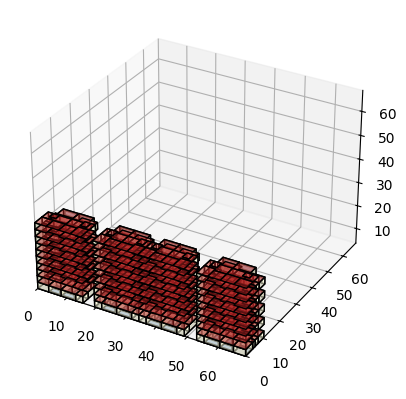

In [4]:
"""Convert a lower/upper maisonette JSON into a 2-level EnergyPlus IDF
using geomeppy/eppy objects throughout.

Key project rules
-----------------
* JSON numberStories controls the number of residential storeys.
* Storey 0 = lower, Storey 1 = upper, then alternate lower/upper.
* Storey 0 starts at z = 3.6 m; every subsequent storey is 2.8 m higher.
* every room polygon becomes an EnergyPlus Zone
* naming uses "Unit", never geomeppy's default "Block"
* HVAC only for livingroom/masterroom/bedroom*
* cooling setpoint = 25 C
* no heating (Always Off)
* dehumidification max RH = 60%, no humidifier
* infiltration:
    - bedroom/masterroom = 0.2 ACH
    - livingroom = 1.0 ACH base with Living_Infiltration_AirCon schedule
      giving 0.2 ACH when AC is on and 1.0 ACH when AC is off
    - other rooms = 1.0 ACH
* floors/ceilings = Adiabatic, NoSun, NoWind
* ordinary exterior walls = Outdoors, SunExposed, WindExposed
* corridor facades = Outdoors, NoSun, WindExposed
* window facades = Outdoors, SunExposed, WindExposed
* window+corridor overlap = NoSun, WindExposed, with window retained
"""

import json, math
from collections import defaultdict
from pathlib import Path

from geomeppy import IDF
from shapely.geometry import LineString, Point, Polygon
from shapely.geometry.polygon import orient
from shapely.validation import explain_validity

# ============================================================
# PATHS / SETTINGS
# ============================================================

IDD_PATH = Path(r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd")
INPUT_JSON = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk863_EM.json")
IDF_TEMPLATE = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\idf_template_SL.idf")

OUTPUT_NORMAL = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk863_EM_normal.idf")
OUTPUT_24H = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk863_EM_24hAC.idf")

BASE_ELEVATION, FLOOR_HEIGHT = 3.6, 2.8
GEOMETRY_TOLERANCE, AREA_TOLERANCE = 1e-5, 1e-7

WALL_CONSTRUCTION = "Project Wall"
FLOOR_CONSTRUCTION = "Project Floor"
ROOF_CONSTRUCTION = "Project Flat Roof"
WINDOW_CONSTRUCTION = "Project External Window"

ALWAYS_ON = "Always On"
ALWAYS_OFF = "Always Off"
AC_NORMAL = "AirCon_normal"
AC_24H = "AirCon_24hr"
LIVING_INFILTRATION = "Living_Infiltration_AirCon"

THERMOSTAT = "Zone Stat"
COOLING_SETPOINT = 25.0
MAX_RH = 60.0


# ============================================================
# HELPERS
# ============================================================

def clean_room(name):
    return str(name).lower().replace("_", "").replace("-", "").replace(" ", "")


def conditioned(room):
    room = clean_room(room)
    return room == "livingroom" or room.startswith(("masterroom", "bedroom"))


def get_obj(idf, obj_type, name):
    return next(
        (o for o in idf.idfobjects[obj_type.upper()]
         if str(o.Name).strip().lower() == name.strip().lower()),
        None,
    )


def pkey(p):
    return round(float(p[0]), 6), round(float(p[1]), 6)


def skey(a, b):
    return tuple(sorted((pkey(a), pkey(b))))


def storey_layout(storey):
    return "lower" if storey % 2 == 0 else "upper"


def elevation(storey):
    z0 = BASE_ELEVATION + storey * FLOOR_HEIGHT
    return z0, z0 + FLOOR_HEIGHT


def normalise_polygon(coords, context="polygon"):
    poly = Polygon(coords)
    if poly.is_valid:
        return orient(poly, sign=1.0)

    fixed = poly.buffer(0)
    if (
        fixed.geom_type == "Polygon"
        and fixed.is_valid
        and abs(fixed.area - poly.area) <= AREA_TOLERANCE
        and fixed.area > AREA_TOLERANCE
    ):
        return orient(fixed, sign=1.0)

    raise ValueError(f"Invalid polygon: {context}. {explain_validity(poly)}")


def intersection_points(g):
    if g.is_empty:
        return
    if g.geom_type == "Point":
        yield g
    elif g.geom_type == "MultiPoint":
        yield from g.geoms
    elif g.geom_type == "LineString":
        c = list(g.coords)
        if c:
            yield Point(c[0])
            yield Point(c[-1])
    elif hasattr(g, "geoms"):
        for sub in g.geoms:
            yield from intersection_points(sub)


def split_boundary(coords, splitters):
    poly = orient(Polygon(coords), sign=1.0)
    ring = list(poly.exterior.coords)[:-1]
    out = []

    for a, b in zip(ring, ring[1:] + ring[:1]):
        edge = LineString([a, b])
        ds = {0.0, edge.length}

        for splitter in splitters:
            for p in intersection_points(edge.intersection(splitter)):
                if edge.distance(p) <= GEOMETRY_TOLERANCE:
                    ds.add(max(0.0, min(edge.length, edge.project(p))))

        ds = sorted(ds)
        for d0, d1 in zip(ds[:-1], ds[1:]):
            if d1 - d0 > GEOMETRY_TOLERANCE:
                p0, p1 = edge.interpolate(d0), edge.interpolate(d1)
                out.append(((p0.x, p0.y), (p1.x, p1.y)))

    return out


def facade_segments(unit):
    out = []
    for f in unit.get("facades", []):
        ftype = str(f.get("type", "")).strip().lower()
        if ftype not in {"window", "corridor"}:
            continue

        pts = f.get("points", [f.get("start"), f.get("end")])
        wwr = float(f.get("WWR", 0.5))

        if not 0 <= wwr < 1:
            raise ValueError(f"Invalid WWR: {wwr}")

        for a, b in zip(pts[:-1], pts[1:]):
            line = LineString([a, b])
            if line.length <= GEOMETRY_TOLERANCE:
                raise ValueError(f"Zero-length facade: {f}")
            out.append((line, ftype, wwr))
    return out


def load_json(path):
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    if "lower" not in data or "upper" not in data:
        raise ValueError("JSON must contain lower and upper.")

    for level in ("lower", "upper"):
        records = []
        for unit_no, unit in data[level].items():
            facade_segments(unit)
            for room, room_data in unit["rooms"].items():
                records.append((unit_no, room, normalise_polygon(
                    room_data["coordinates"], f"{level} Unit {unit_no} {room}"
                )))

        for i, (ua, ra, pa) in enumerate(records):
            for ub, rb, pb in records[i + 1:]:
                area = pa.intersection(pb).area
                if area > AREA_TOLERANCE:
                    raise ValueError(
                        f"Overlap: {level} Unit {ua} {ra} <-> Unit {ub} {rb}: {area:.6f} m2"
                    )

    return data


def init_idf():
    try:
        IDF.setiddname(str(IDD_PATH))
    except Exception:
        pass
    return IDF(str(IDF_TEMPLATE))


# ============================================================
# IDF OBJECTS
# ============================================================

def add_zone(idf, name):
    return idf.newidfobject(
        "ZONE", Name=name, Direction_of_Relative_North=0,
        X_Origin=0, Y_Origin=0, Z_Origin=0, Type=1, Multiplier=1,
        Ceiling_Height="autocalculate", Volume="autocalculate",
        Floor_Area="autocalculate", Part_of_Total_Floor_Area="Yes",
    )


def add_surface(idf, name, stype, construction, zone, bc, bc_obj, sun, wind, vertices):
    obj = idf.newidfobject(
        "BUILDINGSURFACE:DETAILED",
        Name=name, Surface_Type=stype, Construction_Name=construction,
        Zone_Name=zone, Outside_Boundary_Condition=bc,
        Outside_Boundary_Condition_Object=bc_obj,
        Sun_Exposure=sun, Wind_Exposure=wind,
        View_Factor_to_Ground="autocalculate",
        Number_of_Vertices=len(vertices),
    )
    for i, (x, y, z) in enumerate(vertices, 1):
        setattr(obj, f"Vertex_{i}_Xcoordinate", float(x))
        setattr(obj, f"Vertex_{i}_Ycoordinate", float(y))
        setattr(obj, f"Vertex_{i}_Zcoordinate", float(z))
    return obj


def add_window(idf, name, wall, a, b, z0, z1, wwr):
    if wwr <= 0:
        return

    hf = max(0.8, min(0.98, math.sqrt(wwr)))
    vf = wwr / hf
    if vf > 0.98:
        vf, hf = 0.98, wwr / 0.98

    ax, ay = a
    bx, by = b
    s, e = (1 - hf) / 2, (1 + hf) / 2

    p1 = (ax + (bx - ax) * s, ay + (by - ay) * s)
    p2 = (ax + (bx - ax) * e, ay + (by - ay) * e)

    h = z1 - z0
    wz0, wz1 = z0 + h * (1 - vf) / 2, z1 - h * (1 - vf) / 2
    vertices = [
        (p1[0], p1[1], wz0), (p2[0], p2[1], wz0),
        (p2[0], p2[1], wz1), (p1[0], p1[1], wz1),
    ]

    obj = idf.newidfobject(
        "FENESTRATIONSURFACE:DETAILED",
        Name=name, Surface_Type="Window",
        Construction_Name=WINDOW_CONSTRUCTION,
        Building_Surface_Name=wall,
        View_Factor_to_Ground="autocalculate",
        Multiplier=1, Number_of_Vertices=4,
    )

    for i, (x, y, z) in enumerate(vertices, 1):
        setattr(obj, f"Vertex_{i}_Xcoordinate", float(x))
        setattr(obj, f"Vertex_{i}_Ycoordinate", float(y))
        setattr(obj, f"Vertex_{i}_Zcoordinate", float(z))


def add_infiltration(idf, zone, room):
    room = clean_room(room)

    if room == "livingroom":
        schedule, ach = LIVING_INFILTRATION, 1.0
    elif room.startswith(("masterroom", "bedroom")):
        schedule, ach = ALWAYS_ON, 0.2
    else:
        schedule, ach = ALWAYS_ON, 1.0

    idf.newidfobject(
        "ZONEINFILTRATION:DESIGNFLOWRATE",
        Name=f"{zone} Infiltration",
        Zone_or_ZoneList_Name=zone,
        Schedule_Name=schedule,
        Design_Flow_Rate_Calculation_Method="AirChanges/Hour",
        Air_Changes_per_Hour=ach,
        Constant_Term_Coefficient=1.0,
        Temperature_Term_Coefficient=0.0,
        Velocity_Term_Coefficient=0.0,
        Velocity_Squared_Term_Coefficient=0.0,
    )


def ensure_thermostat(idf):
    t = get_obj(idf, "HVACTEMPLATE:THERMOSTAT", THERMOSTAT)
    if t is None:
        t = idf.newidfobject("HVACTEMPLATE:THERMOSTAT", Name=THERMOSTAT)

    t.Heating_Setpoint_Schedule_Name = ""
    t.Constant_Heating_Setpoint = ""
    t.Cooling_Setpoint_Schedule_Name = ""
    t.Constant_Cooling_Setpoint = COOLING_SETPOINT


def add_hvac(idf, zone):
    idf.newidfobject(
        "HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM",
        Zone_Name=zone,
        Template_Thermostat_Name=THERMOSTAT,
        System_Availability_Schedule_Name=AC_NORMAL,
        Heating_Limit="NoLimit",
        Heating_Availability_Schedule_Name=ALWAYS_OFF,
        Cooling_Limit="NoLimit",
        Cooling_Availability_Schedule_Name=AC_NORMAL,
        Dehumidification_Control_Type="Humidistat",
        Dehumidification_Setpoint=MAX_RH,
        Humidification_Control_Type="None",
        Humidification_Setpoint="",
        Outdoor_Air_Method="None",
    )


# ============================================================
# BUILD NORMAL MODEL ONCE
# ============================================================

def build_normal():
    data = load_json(INPUT_JSON)
    idf = init_idf()
    ensure_thermostat(idf)

    stories = int(data.get("numberStories", 2))
    zones, by_story = [], defaultdict(list)

    for storey in range(stories):
        level = storey_layout(storey)

        for unit_no, unit in data[level].items():
            facades = facade_segments(unit)

            for room, room_data in unit["rooms"].items():
                poly = normalise_polygon(
                    room_data["coordinates"],
                    f"Storey {storey} Unit {unit_no} {room}",
                )

                zone = f"Unit {unit_no}_{room} Storey {storey}"
                add_zone(idf, zone)

                record = {
                    "storey": storey, "level": level, "unit": str(unit_no),
                    "room": room, "zone": zone, "polygon": poly,
                    "facades": facades,
                }
                zones.append(record)
                by_story[storey].append(record)

    for storey, records in by_story.items():
        splitters = (
            [r["polygon"].boundary for r in records]
            + [line for r in records for line, _, _ in r["facades"]]
        )
        for r in records:
            r["segments"] = split_boundary(
                list(r["polygon"].exterior.coords)[:-1],
                splitters,
            )

    owners = defaultdict(list)
    surface_names = {}

    for r in zones:
        for i, (a, b) in enumerate(r["segments"]):
            owners[(r["storey"], skey(a, b))].append((r, i, a, b))
            surface_names[(r["zone"], i)] = f"{r['zone']} Wall {i + 1:03d}"

    pending_windows = []

    for r in zones:
        z0, z1 = elevation(r["storey"])
        coords = list(r["polygon"].exterior.coords)[:-1]

        add_surface(
            idf, f"{r['zone']} Floor", "Floor", FLOOR_CONSTRUCTION, r["zone"],
            "Adiabatic", "", "NoSun", "NoWind",
            [(x, y, z0) for x, y in reversed(coords)],
        )

        add_surface(
            idf, f"{r['zone']} Ceiling", "Roof", ROOF_CONSTRUCTION, r["zone"],
            "Adiabatic", "", "NoSun", "NoWind",
            [(x, y, z1) for x, y in coords],
        )

        for i, (a, b) in enumerate(r["segments"]):
            wall = surface_names[(r["zone"], i)]
            shared = [
                x for x in owners[(r["storey"], skey(a, b))]
                if x[0]["zone"] != r["zone"]
            ]

            segment = LineString([a, b])
            labels, wwrs = [], []

            for line, ftype, wwr in r["facades"]:
                if line.buffer(GEOMETRY_TOLERANCE).covers(segment):
                    labels.append(ftype)
                    if ftype == "window":
                        wwrs.append(wwr)

            has_window = "window" in labels
            has_corridor = "corridor" in labels

            if shared:
                other, other_i, _, _ = shared[0]
                bc = "Surface"
                bc_obj = surface_names[(other["zone"], other_i)]
                sun, wind, make_window = "NoSun", "NoWind", False
            else:
                bc, bc_obj = "Outdoors", ""
                sun = "NoSun" if has_corridor else "SunExposed"
                wind, make_window = "WindExposed", has_window

            add_surface(
                idf, wall, "Wall", WALL_CONSTRUCTION, r["zone"],
                bc, bc_obj, sun, wind,
                [(a[0], a[1], z0), (b[0], b[1], z0),
                 (b[0], b[1], z1), (a[0], a[1], z1)],
            )

            if make_window:
                if len({round(x, 8) for x in wwrs}) > 1:
                    raise ValueError(f"Conflicting WWRs on {wall}: {wwrs}")
                pending_windows.append(
                    (f"{wall} Window", wall, a, b, z0, z1, wwrs[0] if wwrs else 0.5)
                )

    for args in pending_windows:
        add_window(idf, *args)

    for r in zones:
        add_infiltration(idf, r["zone"], r["room"])

    for r in zones:
        if conditioned(r["room"]):
            add_hvac(idf, r["zone"])

    return idf


# ============================================================
# NORMAL -> 24H EDIT
# ============================================================

def change_to_24h(idf):
    for hvac in idf.idfobjects["HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM"]:
        hvac.System_Availability_Schedule_Name = AC_24H
        hvac.Cooling_Availability_Schedule_Name = AC_24H

    for infil in idf.idfobjects["ZONEINFILTRATION:DESIGNFLOWRATE"]:
        if "livingroom" in infil.Zone_or_ZoneList_Name.lower():
            infil.Schedule_Name = ALWAYS_ON
            infil.Air_Changes_per_Hour = 0.2


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    idf = build_normal()

    idf.save(str(OUTPUT_NORMAL), lineendings="default", encoding="latin-1")
    print(f"Saved: {OUTPUT_NORMAL}")

    change_to_24h(idf)

    idf.save(str(OUTPUT_24H), lineendings="default", encoding="latin-1")
    print(f"Saved: {OUTPUT_24H}")

    idf.view_model()


Stage 5: Created different materials
- Read blk863_EM_24hrAC.idf and _normal.idf inside tampines_idf\blk863_EM and the materials inside
- Based on my 5 materials (ConcreteWall, WhitePaint, CoolPaint, EvaporativePaint and Greenwall), change project wall only, dont change roof, ceiling and floor
- Create folders /annual in the /blk863_EM folder if it doesn't exist
- Create folders like blk863_EM_{material}_AC24h or _ACnormal suffix if they dont exist, and ensure idf files created follows same naming convention
- Ensure all output reporting frequency is monthly instead of hourly

In [6]:
from copy import deepcopy
from pathlib import Path

from geomeppy import IDF


# ============================================================
# PATHS
# ============================================================

IDD_PATH = Path(
    r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
)

BASE_FOLDER = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM"
)

NORMAL_IDF = BASE_FOLDER / "blk863_EM_normal.idf"
AC24H_IDF = BASE_FOLDER / "blk863_EM_24hAC.idf"
OUTPUT_ROOT = BASE_FOLDER / "annual"

# ============================================================
# SETTINGS
# ============================================================

MATERIALS = [
    "ConcreteWall",
    "WhitePaint",
    "CoolPaint",
    "EvaporativePaint",
    "Greenwall",
]
PROJECT_WALL = "Project Wall"

# ============================================================
# HELPERS
# ============================================================

def get_object(idf, object_type, name):
    return next(
        (
            obj
            for obj in idf.idfobjects[object_type.upper()]
            if str(obj.Name).strip().lower() == name.lower()
        ),
        None,
    )

def set_wall_material(idf, material):
    construction = get_object(
        idf,
        "CONSTRUCTION",
        PROJECT_WALL,
    )

    if construction is None:
        raise ValueError(
            f"{PROJECT_WALL} construction not found."
        )

    construction.Outside_Layer = material

def set_monthly_outputs(idf):
    for obj in idf.idfobjects["OUTPUT:VARIABLE"]:
        obj.Reporting_Frequency = "Monthly"

    for object_type in (
        "OUTPUT:METER",
        "OUTPUT:METER:METERFILEONLY",
        "OUTPUT:METER:CUMULATIVE",
        "OUTPUT:METER:CUMULATIVE:METERFILEONLY",
    ):
        try:
            objects = idf.idfobjects[object_type]
        except KeyError:
            continue

        for obj in objects:
            if hasattr(obj, "Reporting_Frequency"):
                obj.Reporting_Frequency = "Monthly"

def create_cases(source_idf, suffix):
    base_idf = IDF(str(source_idf))

    existing_materials = {
        obj.Name.lower()
        for obj in base_idf.idfobjects["MATERIAL"]
    }

    for material in MATERIALS:
        if material.lower() not in existing_materials:
            raise ValueError(
                f"Material not found: {material}"
            )

        idf = deepcopy(base_idf)

        set_wall_material(
            idf,
            material,
        )

        set_monthly_outputs(idf)

        case_name = (
            f"blk863_EM_{material}_{suffix}"
        )

        case_folder = (
            OUTPUT_ROOT / case_name
        )

        case_folder.mkdir(
            parents=True,
            exist_ok=True,
        )

        output_idf = (
            case_folder
            / f"{case_name}.idf"
        )

        idf.save(
            str(output_idf),
            lineendings="default",
            encoding="latin-1",
        )

        print(f"Saved: {output_idf}")


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    try:
        IDF.setiddname(
            str(IDD_PATH)
        )
    except Exception:
        pass

    OUTPUT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    create_cases(
        NORMAL_IDF,
        "ACnormal",
    )

    create_cases(
        AC24H_IDF,
        "AC24h",
    )

Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual\blk863_EM_ConcreteWall_ACnormal\blk863_EM_ConcreteWall_ACnormal.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual\blk863_EM_WhitePaint_ACnormal\blk863_EM_WhitePaint_ACnormal.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual\blk863_EM_CoolPaint_ACnormal\blk863_EM_CoolPaint_ACnormal.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual\blk863_EM_EvaporativePaint_ACnormal\blk863_EM_EvaporativePaint_ACnormal.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\annual\blk863_EM_Greenwall_ACnormal\blk863_EM_Greenwall_ACnormal.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapo

Stage 6: Multistory HDB 3 days
- Repeat /annual but for /3 days
- The naming convention is "blk864_concrete_AC24h_3days"
- Ensure the dates match in the idf created matches the uploaded 3 day weatherfile
- Get hourly livingroom zone mean temp as output variable for all units at story 0, 4 and 8 as benchmark to compare paint effects on not just energy load but also on temp (thermal comfort)
- Finally change all output:variable frequency from monthly to hourly

In [ ]:
from copy import deepcopy
from datetime import date
from pathlib import Path
from geomeppy import IDF

IDD_PATH = Path(
    r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
)

BASE = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM"
)

NORMAL_IDF = BASE / "blk863_EM_normal.idf"
AC24H_IDF = BASE / "blk863_EM_24hAC.idf"

WEATHER_FILE = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\resources\SGP_Singapore_20180209_wind1.73_3days.epw"
)

OUTPUT_ROOT = BASE / "3 days"

MATERIALS = {
    "ConcreteWall": "ConcreteWall",
    "WhitePaint": "WhitePaint",
    "CoolPaint": "CoolPaint",
    "EvaporativePaint": "EvaporativePaint",
    "Greenwall": "Greenwall",
}

PROJECT_WALL = "Project Wall"
TEMP_STORIES = {0, 4, 8}
TEMP_VARIABLE = "Zone Mean Air Temperature"


def get_obj(idf, obj_type, name):
    return next(
        (o for o in idf.idfobjects[obj_type.upper()]
         if str(o.Name).strip().lower() == name.strip().lower()),
        None,
    )


def get_epw_dates(path):
    dates = []
    for row in Path(path).read_text(encoding="utf-8", errors="ignore").splitlines()[8:]:
        cols = row.split(",")
        try:
            dates.append(date(int(cols[0]), int(cols[1]), int(cols[2])))
        except (ValueError, IndexError):
            pass

    if not dates:
        raise ValueError("No valid EPW weather rows found.")

    start, end = min(dates), max(dates)
    return start, end, start.strftime("%A")


def prepare_idf(idf, material, start, end, weekday):
    wall = get_obj(idf, "CONSTRUCTION", PROJECT_WALL)
    if wall is None:
        raise ValueError(f"{PROJECT_WALL} not found.")
    wall.Outside_Layer = material

    runs = idf.idfobjects["RUNPERIOD"]
    if not runs:
        runs = [idf.newidfobject("RUNPERIOD", Name="3 Day Run")]

    for run in runs:
        run.Begin_Month = start.month
        run.Begin_Day_of_Month = start.day
        run.End_Month = end.month
        run.End_Day_of_Month = end.day
        run.Day_of_Week_for_Start_Day = weekday

    for out in idf.idfobjects["OUTPUT:VARIABLE"]:
        out.Reporting_Frequency = "Hourly"

    existing = {
        (str(o.Key_Value).strip().lower(), str(o.Variable_Name).strip().lower())
        for o in idf.idfobjects["OUTPUT:VARIABLE"]
    }

    for zone in idf.idfobjects["ZONE"]:
        name = str(zone.Name)
        low = name.lower()

        if "livingroom" not in low:
            continue

        if not any(f"storey {s}" in low for s in TEMP_STORIES):
            continue

        key = (low, TEMP_VARIABLE.lower())

        if key not in existing:
            idf.newidfobject(
                "OUTPUT:VARIABLE",
                Key_Value=name,
                Variable_Name=TEMP_VARIABLE,
                Reporting_Frequency="Hourly",
            )


def create_cases(source, ac_suffix, start, end, weekday):
    base_idf = IDF(str(source))

    existing_materials = {
        str(o.Name).strip().lower()
        for o in base_idf.idfobjects["MATERIAL"]
    }

    for material, short_name in MATERIALS.items():
        if material.lower() not in existing_materials:
            raise ValueError(f"Material not found: {material}")

        idf = deepcopy(base_idf)
        prepare_idf(idf, material, start, end, weekday)

        case = f"blk863_EM_{short_name}_{ac_suffix}_3days"
        folder = OUTPUT_ROOT / case
        folder.mkdir(parents=True, exist_ok=True)

        output = folder / f"{case}.idf"
        idf.save(str(output), lineendings="default", encoding="latin-1")
        print(f"Saved: {output}")


if __name__ == "__main__":
    try:
        IDF.setiddname(str(IDD_PATH))
    except Exception:
        pass

    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

    start, end, weekday = get_epw_dates(WEATHER_FILE)
    print(f"EPW: {start:%d %b %Y} to {end:%d %b %Y}")

    create_cases(NORMAL_IDF, "ACnormal", start, end, weekday)
    create_cases(AC24H_IDF, "AC24h", start, end, weekday)


EPW: 08 Feb 2018 to 10 Feb 2018
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days\blk863_EM_ConcreteWall_ACnormal_3days\blk863_EM_ConcreteWall_ACnormal_3days.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days\blk863_EM_WhitePaint_ACnormal_3days\blk863_EM_WhitePaint_ACnormal_3days.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days\blk863_EM_CoolPaint_ACnormal_3days\blk863_EM_CoolPaint_ACnormal_3days.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days\blk863_EM_EvaporativePaint_ACnormal_3days\blk863_EM_EvaporativePaint_ACnormal_3days.idf
Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863_EM\3 days\blk863_EM_Greenwall_ACnormal_3days\blk863_EM_